Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo y520\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo y520\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "C:\Users\Lenovo y520\AppData\Local\Programs\Python\Python313\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


Fetching LFW dataset...
Total samples: 5985
Number of people: 423

Selected 6 people:
  - Vicente Fox (32 images)
  - Paul Burrell (11 images)
  - Pierce Brosnan (15 images)
  - Bob Graham (6 images)
  - George Robertson (22 images)
  - Mike Weir (11 images)
✓ Vicente Fox - Image 1: Face detected (MTCNN, conf: 1.000)
✗ Vicente Fox - Image 2: No face detected
✓ Paul Burrell - Image 1: Face detected (MTCNN, conf: 0.999)
✓ Paul Burrell - Image 2: Face detected (MTCNN, conf: 0.997)
✓ Pierce Brosnan - Image 1: Face detected (Haar, conf: 0.900)
✓ Pierce Brosnan - Image 2: Face detected (MTCNN, conf: 0.983)
✓ Bob Graham - Image 1: Face detected (MTCNN, conf: 0.997)
✓ Bob Graham - Image 2: Face detected (MTCNN, conf: 1.000)
✓ George Robertson - Image 1: Face detected (Haar, conf: 0.900)
✓ George Robertson - Image 2: Face detected (MTCNN, conf: 1.000)
✓ Mike Weir - Image 1: Face detected (Haar, conf: 0.900)
✗ Mike Weir - Image 2: No face detected


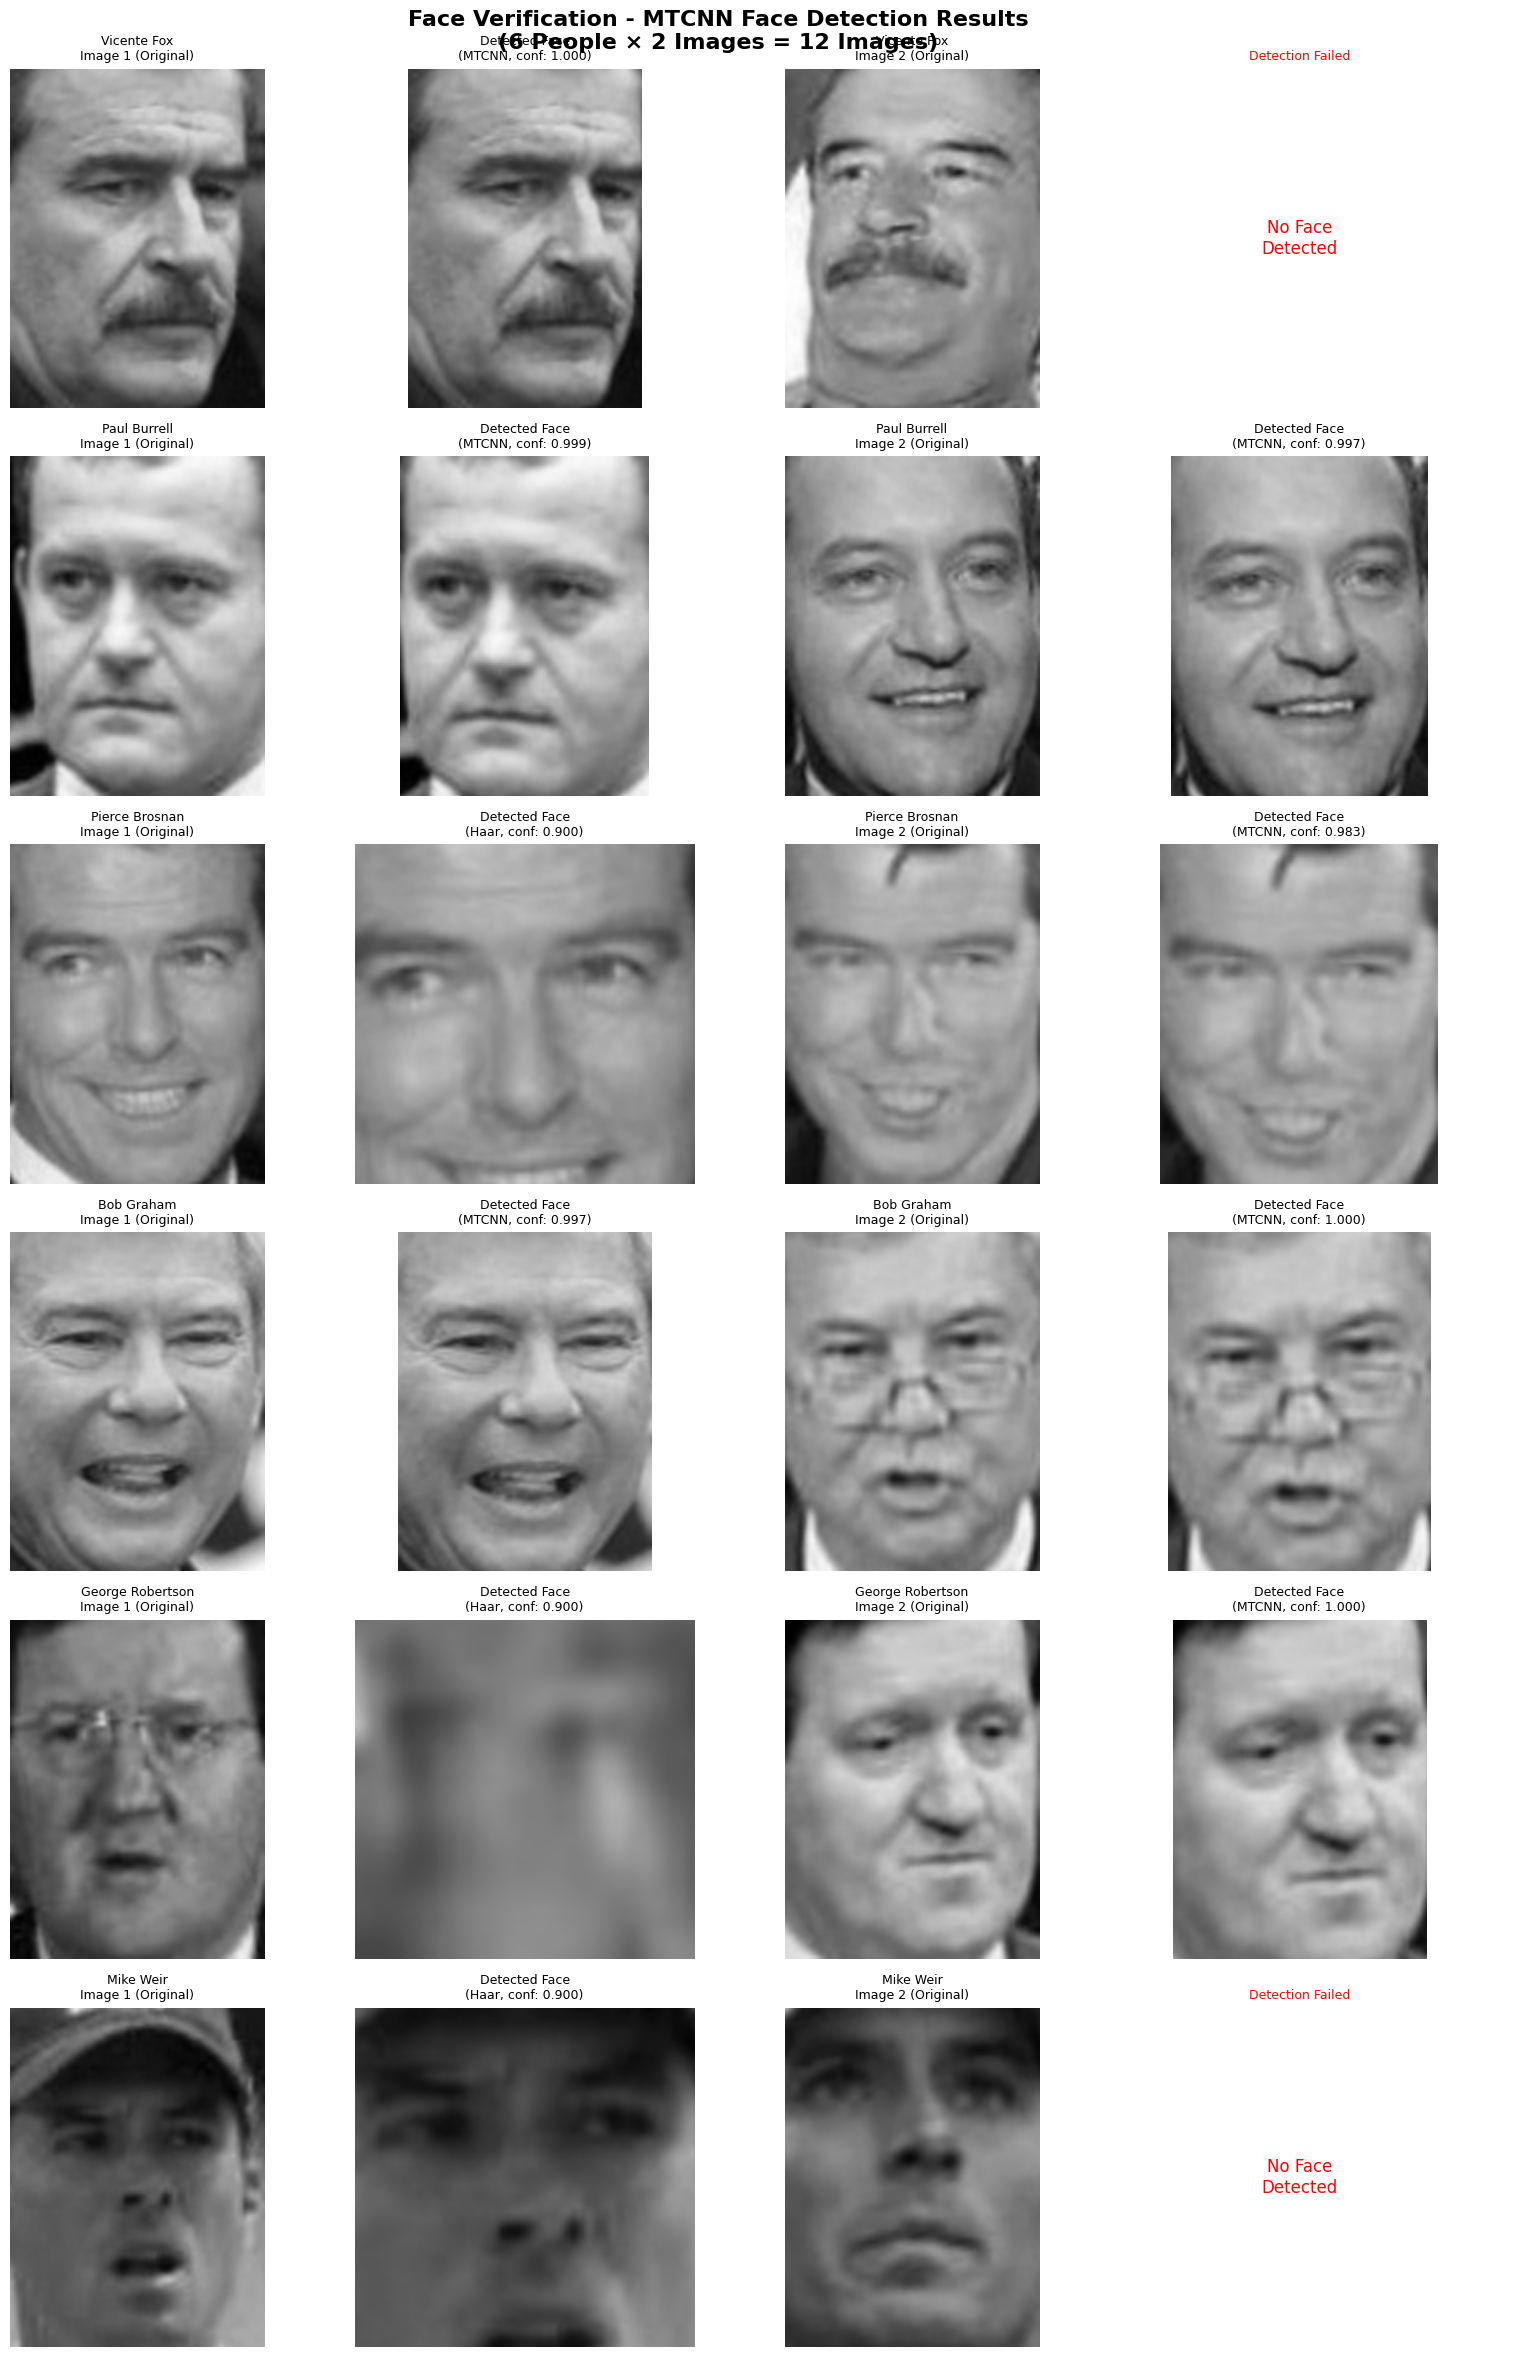


✓ Results saved to: face_verification_results.png

SUMMARY
Total Images: 12
Faces Detected: 10 (83.3%)


In [14]:
"""
Face Verification using MTCNN Face Detection
Assignment: Pertemuan 1 - Praktikum Pembelajaran Mesin
Course: MMAI1004 - Pembelajaran Mesin

This script performs face detection using MTCNN on the LFW dataset
for face verification purposes.
"""

# Import necessary libraries
from mtcnn import MTCNN
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from collections import Counter
import os

# Configure GPU (if available)
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.Session(config=config)

# Initialize MTCNN detector
detector = MTCNN()

# Load Haar Cascade as backup detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def upscale_image(img, target_size=(600, 800)):
    """Upscale grayscale image to target size for better detection"""
    img_uint8 = (img * 255).astype(np.uint8)
    img_rgb = np.stack([img_uint8, img_uint8, img_uint8], axis=-1)
    img_resized = cv2.resize(img_rgb, target_size, interpolation=cv2.INTER_CUBIC)
    return img_resized

def detect_face_haar(img):
    """Detect face using Haar Cascade as fallback"""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)
    
    if len(faces) > 0:
        largest_face = max(faces, key=lambda f: f[2] * f[3])
        x, y, w, h = largest_face
        face_crop = img[y:y+h, x:x+w]
        return face_crop, largest_face, 0.9
    return None, None, 0

def main():
    # Fetch LFW dataset
    print("Fetching LFW dataset...")
    lfw = fetch_lfw_people(min_faces_per_person=5, resize=1.0, download_if_missing=True)
    
    print(f"Total samples: {len(lfw.data)}")
    print(f"Number of people: {len(lfw.target_names)}")
    
    # Select 6 people with at least 2 images each
    person_counts = Counter(lfw.target)
    selected_person_ids = []
    for pid, count in person_counts.items():
        if count >= 2 and len(selected_person_ids) < 6:
            selected_person_ids.append(pid)
    
    print(f"\nSelected 6 people:")
    for pid in selected_person_ids:
        print(f"  - {lfw.target_names[pid]} ({person_counts[pid]} images)")
    
    # Prepare images
    face_data = {}
    for pid in selected_person_ids:
        person_name = lfw.target_names[pid]
        indices = np.where(lfw.target == pid)[0][:2]
        
        face_data[person_name] = []
        for idx in indices:
            img_upscaled = upscale_image(lfw.images[idx])
            face_data[person_name].append(img_upscaled)
    
    # Apply face detection
    face_results = {}
    
    for person_name, images in face_data.items():
        face_results[person_name] = []
        
        for i, img in enumerate(images):
            try:
                detections = detector.detect_faces(img)
                
                if len(detections) > 0:
                    detection = detections[0]
                    bbox = detection['box']
                    confidence = detection['confidence']
                    
                    x, y, w, h = bbox
                    x = max(0, x)
                    y = max(0, y)
                    
                    face_crop = img[y:y+h, x:x+w]
                    
                    face_results[person_name].append({
                        'original': img,
                        'face_crop': face_crop,
                        'bbox': bbox,
                        'confidence': confidence,
                        'detected': True,
                        'image_num': i + 1,
                        'method': 'MTCNN'
                    })
                    print(f"✓ {person_name} - Image {i+1}: Face detected (MTCNN, conf: {confidence:.3f})")
                else:
                    raise ValueError("No face detected")
                    
            except Exception as e:
                # Try Haar Cascade as fallback
                face_crop, bbox, conf = detect_face_haar(img)
                if face_crop is not None:
                    face_results[person_name].append({
                        'original': img,
                        'face_crop': face_crop,
                        'bbox': bbox,
                        'confidence': conf,
                        'detected': True,
                        'image_num': i + 1,
                        'method': 'Haar'
                    })
                    print(f"✓ {person_name} - Image {i+1}: Face detected (Haar, conf: {conf:.3f})")
                else:
                    face_results[person_name].append({
                        'original': img,
                        'face_crop': None,
                        'bbox': None,
                        'confidence': 0,
                        'detected': False,
                        'image_num': i + 1,
                        'method': 'None'
                    })
                    print(f"✗ {person_name} - Image {i+1}: No face detected")
    
    # Create visualization
    fig, axes = plt.subplots(6, 4, figsize=(16, 24))
    fig.suptitle('Face Verification - MTCNN Face Detection Results\n(6 People × 2 Images = 12 Images)', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    row = 0
    for person_name, results in face_results.items():
        for i, r in enumerate(results):
            col = i * 2
            
            # Show original image
            ax_orig = axes[row, col]
            ax_orig.imshow(r['original'])
            ax_orig.set_title(f'{person_name}\nImage {r["image_num"]} (Original)', fontsize=9)
            ax_orig.axis('off')
            
            # Show detected face
            ax_face = axes[row, col + 1]
            if r['detected'] and r['face_crop'] is not None:
                ax_face.imshow(r['face_crop'])
                ax_face.set_title(f'Detected Face\n({r["method"]}, conf: {r["confidence"]:.3f})', fontsize=9)
            else:
                ax_face.text(0.5, 0.5, 'No Face\nDetected', ha='center', va='center', 
                            fontsize=12, color='red')
                ax_face.set_title('Detection Failed', fontsize=9, color='red')
            ax_face.axis('off')
        
        row += 1
    
    plt.tight_layout()
    plt.savefig('face_verification_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Results saved to: face_verification_results.png")
    
    # Print summary
    total = sum(len(r) for r in face_results.values())
    detected = sum(1 for r_list in face_results.values() for r in r_list if r['detected'])
    
    print(f"\n{'='*60}")
    print("SUMMARY")
    print(f"{'='*60}")
    print(f"Total Images: {total}")
    print(f"Faces Detected: {detected} ({detected/total*100:.1f}%)")
    print(f"{'='*60}")

if __name__ == "__main__":
    main()